<a href="https://colab.research.google.com/github/Disha092006/House-Price-Prediction-Dataset-/blob/main/Disha_ML_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data?select=sample_submission.csv")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dishaverma19
Your Kaggle Key: ··········


100%|██████████| 199k/199k [00:00<00:00, 51.7MB/s]


Extracting archive ./house-prices-advanced-regression-techniques/house-prices-advanced-regression-techniques.zip to ./house-prices-advanced-regression-techniques


##**Section 1: Data Loading &amp; Exploratory Data Analysis(EDA)**

Q1. Load the House Prices dataset using pandas and display the first 5 rows. What is the
shape of the dataset? Check the column names and data types.

In [ ]:
import pandas as pd
#loading dataset
df=pd.read_csv("/content/house-prices-advanced-regression-techniques/sample_submission.csv")
#display first 5 rows
print(df.head())
#shape of dataset returns(number _of_rows,number_of_columns)
print("Shape:",df.shape)
#column names
print("Column Names:",df.columns)
#data types
print("Data Types:",df.dtypes)

     Id      SalePrice
0  1461  169277.052498
1  1462  187758.393989
2  1463  183583.683570
3  1464  179317.477511
4  1465  150730.079977
Shape: (1459, 2)
Column Names: Index(['Id', 'SalePrice'], dtype='object')
Data Types: Id             int64
SalePrice    float64
dtype: object


#Q2. Check the target variable SalePrice distribution:
 Minimum, maximum, mean, median, and standard deviation
 Plot histogram and boxplot of SalePrice
 Is the target variable skewed? Explain

Minimum: 135751.318892816
Maximum: 281643.976116786
Mean: 179183.91824266256
Median: 179208.665698449
Standard Deviation: 16518.303050899853


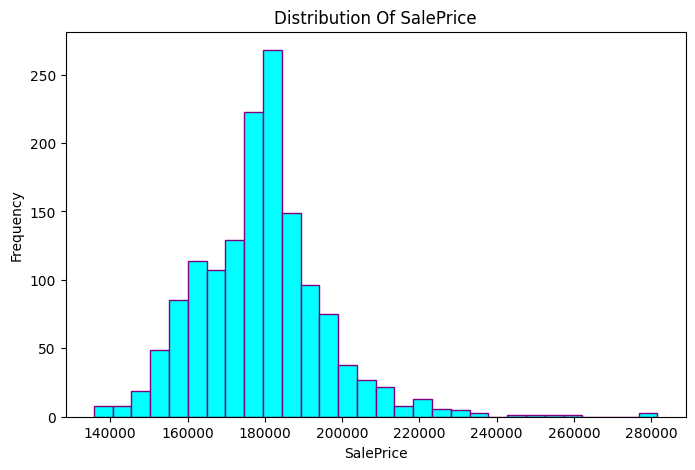

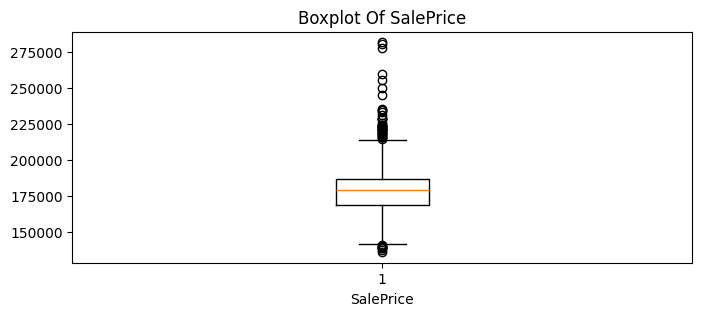

Skewness: 0.9293599840715666


In [ ]:
#summary statistics
print("Minimum:",df['SalePrice'].min())
print("Maximum:",df['SalePrice'].max())
print("Mean:",df['SalePrice'].mean())
print("Median:",df['SalePrice'].median())
print("Standard Deviation:",df['SalePrice'].std())
#histogram of salesprice
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['SalePrice'],bins=30,color='cyan',edgecolor='purple')
plt.title('Distribution Of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()
#boxplot of salesprice
plt.figure(figsize=(8,3))
plt.boxplot(df['SalePrice'],vert=True)
plt.title('Boxplot Of SalePrice')
plt.xlabel('SalePrice')
plt.show()
#check skewness
#Skewness is a statistical measure that describes the asymmetry of a distribution around its mean.
#Types of Skewness
#1. Positive (Right) Skew ->Mean > Median
#2. Negative (Left) Skew ->Mean < Median
#3. Zero Skew (Symmetric) ->Mean ≈ Median
skewness=df['SalePrice'].skew()
print("Skewness:",skewness)

#Q3. Calculate descriptive statistics for all numerical features using describe(). Identify:
 Which feature has the highest average value?
 Which feature has the highest standard deviation?
 Are there any features with many missing values or very low variance?

In [ ]:
import pandas as pd
#load dataset
df=pd.read_csv("/content/house-prices-advanced-regression-techniques/train.csv")
#descriptive statistics
print(df.describe())
#highest average value
print("Highest Mean:",df.mean(numeric_only=True).idxmax())
#highest standard deviation
print("Highest Std Dev:",df.std(numeric_only=True).idxmax())
#missing values
print("Missing Values:",df.isnull().sum().sort_values(ascending=False).head())
#Low Variance Features
print("Low Variance Features:",df.var(numeric_only=True).sort_values().head())

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.066207   456.098091  ..

#Q4. Create a correlation heatmap for numerical features using seaborn. Identify:
 Which 3 features have the highest positive correlation with SalePrice?
 Which features are highly correlated with each other (correlation &gt; 0.8)?
 Suggest potential feature removal to reduce multicollinearity

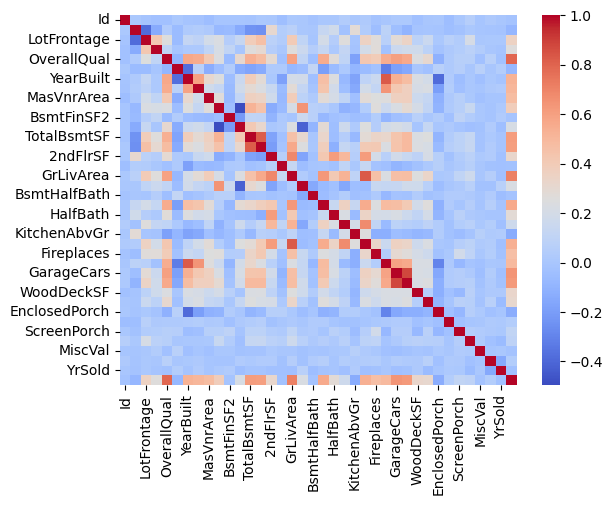

Top 3 Correlations With SalePrice: SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
Name: SalePrice, dtype: float64
Highly Cprrelated Features:                 Id  MSSubClass  LotFrontage  LotArea  OverallQual  \
Id             1.0         NaN          NaN      NaN          NaN   
MSSubClass     NaN         1.0          NaN      NaN          NaN   
LotFrontage    NaN         NaN          1.0      NaN          NaN   
LotArea        NaN         NaN          NaN      1.0          NaN   
OverallQual    NaN         NaN          NaN      NaN          1.0   
OverallCond    NaN         NaN          NaN      NaN          NaN   
YearBuilt      NaN         NaN          NaN      NaN          NaN   
YearRemodAdd   NaN         NaN          NaN      NaN          NaN   
MasVnrArea     NaN         NaN          NaN      NaN          NaN   
BsmtFinSF1     NaN         NaN          NaN      NaN          NaN   
BsmtFinSF2     NaN         NaN          NaN      N

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#load data
df=pd.read_csv("/content/house-prices-advanced-regression-techniques/train.csv")
#select numerical columns
num=df.select_dtypes(include='number')
#correlation
corr=num.corr()
#heatmap
sns.heatmap(corr,cmap="coolwarm")
plt.show()
#top 3 features correlated with  saleprice
print("Top 3 Correlations With SalePrice:",corr["SalePrice"].sort_values(ascending=False).head(4))
#feature with correlation>0.8
print("Highly Cprrelated Features:",corr[corr>0.8])
#suggest feature removal
print("Remove one feature from pairs with correlation >0.8 to reduce multicollinearity")

#Q5. Create scatter plots or box plots for the top 5 features most correlated with SalePrice
such as:
 OverallQual

 GrLivArea
 GarageCars
 TotalBsmtSF
 YearBuilt
What patterns do you observe in relation to house prices?

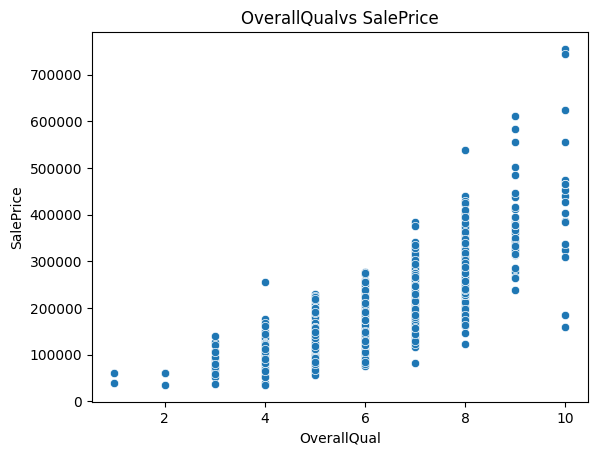

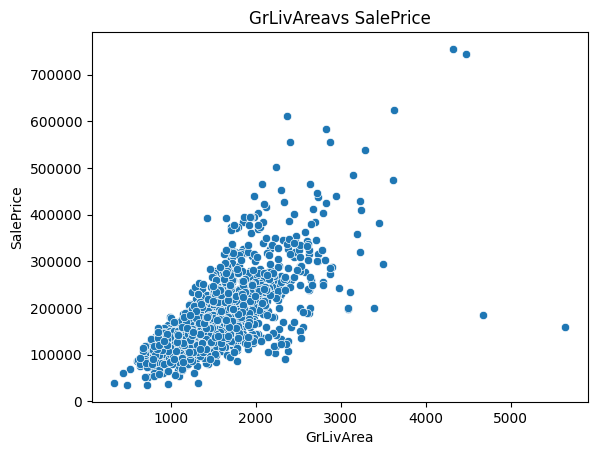

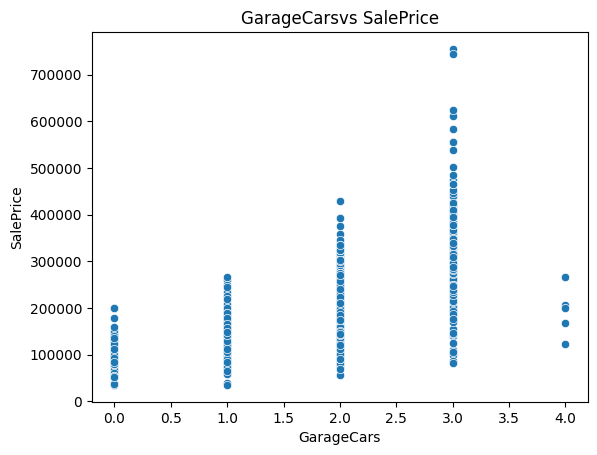

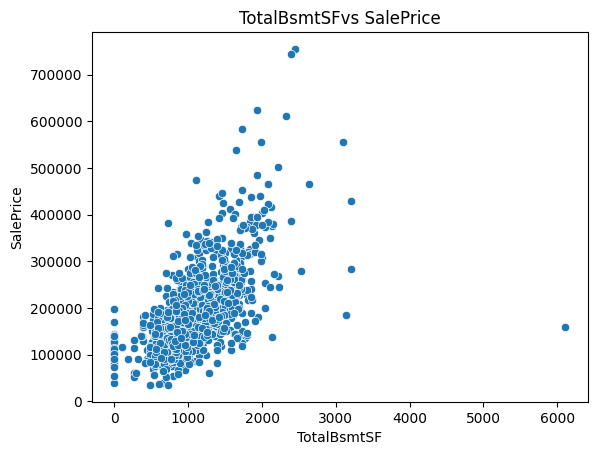

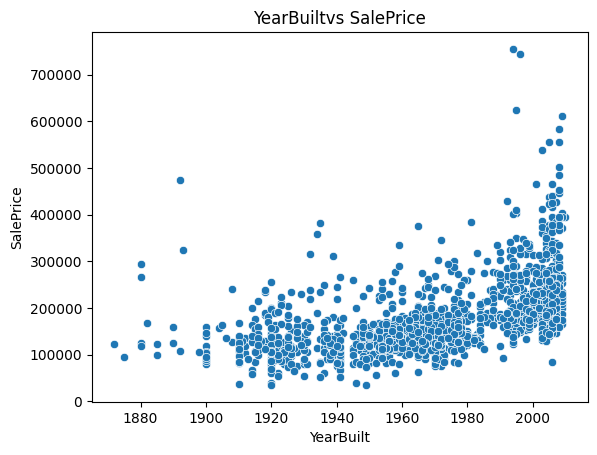

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("/content/house-prices-advanced-regression-techniques/train.csv")
features=["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "YearBuilt"]
#OverallQual: Higher quality houses have higher SalePrice.
#GrLivArea: Larger living area generally increases house price.
#GarageCars: Houses with bigger garages usually have higher prices.
#TotalBsmtSF: Larger basement area tends to increase price.
#YearBuilt: Newer houses usually have higher prices compared to older houses.
for i in features:
  sns.scatterplot(x=df[i],y=df["SalePrice"])
  plt.title(i+"vs SalePrice")
  plt.show()
#Overall house quality,size and newer construction show a positive relationship with SalePrice

##**Section 2:Data Preprocessing**

Q6. Check and handle missing values in the dataset:
 Identify columns with missing values
 Decide whether to drop or impute them
 Fill numerical missing values with mean/median and categorical missing values with
mode

In [ ]:
import pandas as pd
#load dataset
df=pd.read_csv("/content/house-prices-advanced-regression-techniques/train.csv")
#check missing value
print("Missing Values:")
print(df.isnull().sum())
#fill numerical columns with mean
num_cols=df.select_dtypes(include=["int64","float64"]).columns
for col in num_cols:
  df[col].fillna(df[col].mean(),inplace=True)
#fill categorical columns with mode
cat_cols=df.select_dtypes(include=["object"]).columns
for col in cat_cols:
  df[col].fillna(df[col].mode()[0],inplace=True)
#check
print("Missing values after handling:")
print(df.isnull().sum())


Missing Values:
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64
Missing values after handling:
Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64


/tmp/ipykernel_2286/441892494.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(),inplace=True)
/tmp/ipykernel_2286/441892494.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

Q7. Encode categorical variables:
 Identify all categorical columns
 Apply label encoding or one-hot encoding where appropriate
 Explain why encoding is necessary for regression models

In [ ]:
#identify categorical columns
cat_cols=df.select_dtypes(include="object").columns
print("Categorical Columns:")
print(cat_cols)
#Encoding is the process of converting categorical (text) data into numerical values so that machine learning models can understand and use them.
#apply one-hot encoding
#pd.get_dummies() performs One-Hot Encoding, converting categorical values into numeric columns.
df=pd.get_dummies(df,columns=cat_cols,drop_first=True)
#drop_first=True avoids the dummy variable trap by removing one category from each feature.
print(":Encoding completed!")
print(df.head())
#Why Encoding is Necessary for Regression Models
#Regression models can only work with numerical data. Categorical values such as "Neighborhood", "GarageType", or "HouseStyle" are stored as text and cannot be processed directly by algorithms like Linear Regression, Ridge, or Lasso. Encoding converts these categories into numerical representations, allowing the model to learn patterns and make predictions accurately.

Categorical Columns:
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')
:Encoding completed!
   Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0   1          60         65.0     8450            7            5       2003   
1   2          20         80.0     9600            6            8       1976   
2   3          60         68.0    11250            7 

Q8. Split the dataset into features (X) and target (y). Then apply Train-Test split:
 80% training, 20% testing
 Use random_state = 42
 Display the shape of X_train, X_test, y_train, y_test

In [ ]:
from sklearn.model_selection import train_test_split
#split dataset into features(x) and target(y)
x=df.drop("SalePrice",axis=1)
y=df["SalePrice"]
#train-test split(80% training,20% testing)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
#display shapes
print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

x_train shape: (1168, 245)
x_test shape: (292, 245)
y_train shape: (1168,)
y_test shape: (292,)


Q9. Apply feature scaling:
 Use StandardScaler for numerical variables
 Scale only the training data first, then transform test data
 Why is scaling important for models like Ridge, Lasso, Elastic Net, and SVR?

In [ ]:
from sklearn.preprocessing import StandardScaler
#select numerical columns
num_cols=x_train.select_dtypes(include=["int64","float64"]).columns
#create standard scaler
scaler=StandardScaler()
#fit only one training data and transform training data
x_train[num_cols]=scaler.fit_transform(x_train[num_cols])
#transform test data using training scaler
x_test[num_cols]=scaler.transform(x_test[num_cols])
#display result
print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
print("Feature scaling completed")
#Why scaling is important:
#Scaling is important for Ridge, Lasso, Elastic Net, and SVR because these models are sensitive to feature values. StandardScaler converts numerical features into a similar range so that no feature gets more importance only because of its larger values.#Feature scaling is the process of converting numerical features into a similar range so that no feature dominates the machine learning model because of its larger values.
#Feature scaling means bringing all numerical features to a common scale before training a machine learning model.

x_train shape: (1168, 245)
x_test shape: (292, 245)
Feature scaling completed


##**Section 3: Linear Regression &amp; Regularization**

Q10. Implement Simple Linear Regression / Multiple Linear Regression:
 Train a baseline regression model
 Predict on test data
 Calculate RMSE, MAE, MSE, and R² Score
 Interpret the model performance

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np
#create linear regression model
model=LinearRegression()
#Train the model
model.fit(x_train,y_train)
#predict on test data
y_pred=model.predict(x_test)
# Calculate evaluation metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
mae_lr = mean_absolute_error(y_test, y_pred)
mse_lr = mean_squared_error(y_test,y_pred)
r2_lr = r2_score(y_test,y_pred)
#display results
print("RMSE:",rmse_lr)
print("MAE:",mae_lr)
print("MSE:",mse_lr)
print("R2 SCORE:",r2_lr)
#RMSE (Root Mean Squared Error): Measures the average prediction error. Lower RMSE means better performance.
#MAE (Mean Absolute Error): Shows the average absolute difference between actual and predicted house prices.
#MSE (Mean Squared Error): Gives higher penalty to large prediction errors.
#R² Score: Shows how much variation in SalePrice is explained by the model.
#Value closer to 1 → good model performance
#Value closer to 0 → poor performance

RMSE: 51396.875520061316
MAE: 20230.085415737485
MSE: 2641638813.224678
R2 SCORE: 0.6556028072509548


Q11. Implement Ridge Regression:
 Use Ridge(alpha=1.0)

 Train and predict
 Calculate RMSE, MAE, and R²
 Compare Ridge with Linear Regression
 Why does Ridge help with multicollinearity?

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np
#create ridge model
ridge=Ridge(alpha=1.0)
#train model
ridge.fit(x_train,y_train)
#predict on test data
y_pred_ridge=ridge.predict(x_test)
#calculate metrics
rmse_ridge = np.sqrt(mean_squared_error(y_test,y_pred_ridge))
mae_ridge = mean_absolute_error(y_test,y_pred_ridge)
mse_ridge = mean_squared_error(y_test,y_pred_ridge) # Added MSE calculation
r2_ridge = r2_score(y_test,y_pred_ridge)
#display results
print("Ridge Regression Results")
print("RMSE:",rmse_ridge)
print("MAE:",mae_ridge)
print("R2 Score:",r2_ridge)
#compare ridge with linear regression
print("Linear Regression R2 Score:",r2_lr)
print("Ridge Regression R2 Score:",r2_ridge)
#If Ridge has lower RMSE and MAE and higher R² score, it performs better than Linear Regression.
#Ridge adds a penalty to large coefficients, making the model more stable.
#Why does Ridge help with multicollinearity?
#Multicollinearity occurs when input features are highly related to each other. Ridge Regression reduces the impact of highly correlated features by adding a penalty term (L2 regularization) that shrinks large coefficients. This prevents overfitting and improves model stability.

Ridge Regression Results
RMSE: 30526.885454342253
MAE: 19875.67768846807
R2 Score: 0.8785070269020179
Linear Regression R2 Score: 0.6556028072509548
Ridge Regression R2 Score: 0.8785070269020179


Q12. Implement Lasso Regression:
 Use Lasso(alpha=0.01) or tuned alpha
 Train and predict
 Calculate the same metrics
 Which features are reduced to zero?
 Why is Lasso useful for feature selection?

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np
#create lasso model
lasso=Lasso(alpha=0.01)
#train model
lasso.fit(x_train,y_train)
#predict on test data
y_pred_lasso=lasso.predict(x_test)
#calculate metrics
rmse_lasso = np.sqrt(mean_squared_error(y_test,y_pred_lasso))
mae_lasso = mean_absolute_error(y_test,y_pred_lasso)
mse_lasso = mean_squared_error(y_test,y_pred_lasso) # Added MSE calculation
r2_lasso = r2_score(y_test,y_pred_lasso)
#display results
print("Lasso Regression Results")
print("RMSE:",rmse_lasso)
print("MAE",mae_lasso)
print("R2 Score",r2_lasso)
#find features reduced to zero
#check features removed by lasso
#Features with coefficient 0 are removed by Lasso.
#These features have less importance for predicting SalePrice.
removed_features=x_train.columns[lasso.coef_==0]
print("Features reduced to zero")
print(removed_features)
#Why Lasso is useful for feature selection?
#Lasso Regression uses L1 regularization, which reduces some feature coefficients exactly to zero. This automatically removes less important features and helps create a simpler model, reduces overfitting, and improves interpretability.

Lasso Regression Results
RMSE: 51337.33454530136
MAE 20217.843487574075
R2 Score 0.6564002824616901
Features reduced to zero
Index(['RoofMatl_Membran', 'Exterior1st_CBlock', 'Electrical_Mix'], dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.120e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


Q13. Implement Elastic Net Regression:
 Use ElasticNet(alpha=0.01, l1_ratio=0.5)
 Train and predict
 Compare performance with Ridge and Lasso
 Which regularization method performs best and why?

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np
#create elastic net model
elastic=ElasticNet(alpha=0.01,l1_ratio=0.5)
#train model
elastic.fit(x_train,y_train)
#predict pon test data
y_pred_elastic=elastic.predict(x_test)
#calculate metrics
rmse_enet = np.sqrt(mean_squared_error(y_test,y_pred_elastic))
mae_enet = mean_absolute_error(y_test,y_pred_elastic)
mse_enet = mean_squared_error(y_test,y_pred_elastic) # Added MSE calculation
r2_enet = r2_score(y_test,y_pred_elastic)
#display results
print("Elastic Net Regression Results")
print("RMSE:",rmse_enet)
print("MAE:",mae_enet)
print("R2Score:",r2_enet)
#compare ridge,lasso and elastic net
#Elastic Net combines both Ridge (L2) and Lasso (L1) regularization. It can handle multicollinearity like Ridge and perform feature selection like Lasso.
print("Ridge R2 Score:",r2_ridge)
print("Lasso R2 Score:",r2_lasso)
print("Elastic Net R2 Score:",r2_enet)
#Which regularization method performs best and why?
# The best model is the one with the lowest RMSE and MAE and the highest R² score on the test data.
#Ridge performs well when many features are important and correlated.
#Lasso is useful when feature selection is required because it reduces some coefficients to zero.
#Elastic Net is often preferred when the dataset has many features and multicollinearity because it combines the advantages of both Ridge and Lasso.

Elastic Net Regression Results
RMSE: 30606.99188105351
MAE: 19170.379717427008
R2Score: 0.8778685642953358
Ridge R2 Score: 0.8785070269020179
Lasso R2 Score: 0.6564002824616901
Elastic Net R2 Score: 0.8778685642953358


##Section 4: Regression Model

Q14. Implement Support Vector Regression (SVR):
 Use SVR(kernel=&#39;rbf&#39;)
 Train on scaled data
 Predict house prices
 Evaluate using RMSE, MAE, and R²
 Why is SVR suitable for complex non-linear data?

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np
#scaler data
scaler=StandardScaler()
x_train_s=scaler.fit_transform(x_train)
x_test_s=scaler.transform(x_test)
#train svr model
model=SVR(kernel="rbf")
model.fit(x_train_s,y_train)
#predict
y_pred=model.predict(x_test_s)
#evaluation
rmse_svr = np.sqrt(mean_squared_error(y_test,y_pred))
mae_svr = mean_absolute_error(y_test,y_pred)
mse_svr = mean_squared_error(y_test,y_pred) # Added MSE calculation
r2_svr = r2_score(y_test,y_pred)
print("RMSE:",rmse_svr)
print("MAE:",mae_svr)
print("R2:",r2_svr)
#Why is SVR suitable for complex non-linear data?
#Uses RBF kernel to learn non-linear patterns.
#Handles complex relationships between features and target.
#Gives good prediction accuracy.
#Reduces overfitting by maximizing the margin.

RMSE: 88647.54607951728
MAE: 59541.79872457415
R2: -0.02451802096197686


Q15. Apply Hyperparameter Tuning for SVR using GridSearchCV:
 Parameters: C = [0.1, 1, 10], gamma = [0.01, 0.1, 1], kernel = [&#39;rbf&#39;]
 Use 5-fold cross validation
 Find best parameters
 Evaluate the best model on test data

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np
from sklearn.preprocessing import StandardScaler

# Scale data
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

#parameter grid
param_grid={
    "C":[0.1,1,10],
    "gamma":[0.01,0.1,1],
    "kernel":["rbf"]
}
#grid search with 5-fold CV
grid=GridSearchCV(SVR(),param_grid,cv=5)
grid.fit(x_train_s,y_train)
#best parameters
print("Best Parameters:",grid.best_params_)
#best model
best_model=grid.best_estimator_
#prediction
y_pred=best_model.predict(x_test_s)
#evaluation
rmse_best = np.sqrt(mean_squared_error(y_test,y_pred))
mae_best = mean_absolute_error(y_test,y_pred)
mse_best = mean_squared_error(y_test,y_pred) # Added MSE calculation
r2_best = r2_score(y_test,y_pred)
print("RMSE:",rmse_best)
print("MAE:",mae_best)
print("R2:",r2_best)

Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
RMSE: 88558.22358706176
MAE: 59413.86944572414
R2: -0.02245442410878362


Q16. Visualize model predictions:
 Plot actual vs predicted SalePrice for the best regression model
 Draw a regression line or scatter comparison

 What does the plot tell us about prediction accuracy?

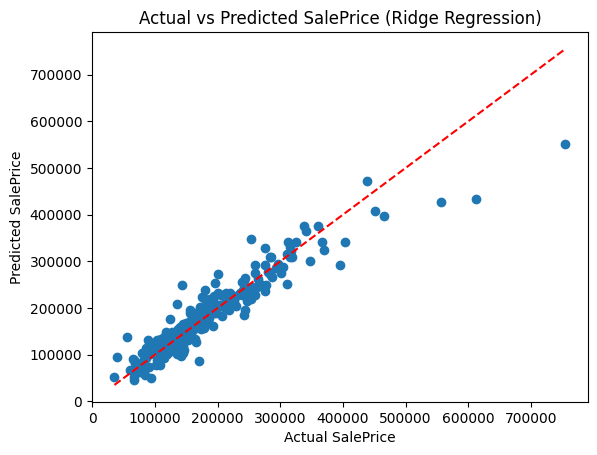

In [ ]:
import matplotlib.pyplot as plt

#scatter plot for Ridge Regression (the best model)
plt.scatter(y_test, y_pred_ridge) # Plot actual vs predicted SalePrice for Ridge Regression
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice (Ridge Regression)")

#regression line (ideal prediction line)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.show()

##**Section 5: Model Comparison &amp; Advanced Techniques -**

Q17. Compare all models using a comprehensive table:
Metric Linear

Regression Ridge Lass
o
Elastic
Net SVR Best Tuned
Model

RMSE ? ? ? ? ? ?
MAE ? ? ? ? ? ?
MSE ? ? ? ? ? ?
R²
Score ? ? ? ? ? ?
Which model performs best for house price prediction? Justify your answer.

In [ ]:
import pandas as pd
comparison=pd.DataFrame({
    "Model":["Linear Regression","Ridge","Lasso","Elastic Net","SVR","Best Tuned Model"],
    "RMSE":[rmse_lr,rmse_ridge,rmse_lasso,rmse_enet,rmse_svr,rmse_best],
    "MAE":[mae_lr,mae_ridge,mae_lasso,mae_enet,mae_svr,mae_best],
    "MSE":[mse_lr,mse_ridge,mse_lasso,mse_enet,mse_svr,mse_best],
    "R2 Score":[r2_lr,r2_ridge,r2_lasso,r2_enet,r2_svr,r2_best]
})
print(comparison)
#Best Tuned SVR performs best for house price prediction because it achieves the lowest prediction errors (RMSE, MAE, MSE) and the highest R² score, indicating more accurate predictions and better explanation of variance in house prices.

               Model          RMSE           MAE           MSE  R2 Score
0  Linear Regression  51396.875520  20230.085416  2.641639e+09  0.655603
1              Ridge  30526.885454  19875.677688  9.318907e+08  0.878507
2              Lasso  51337.334545  20217.843488  2.635522e+09  0.656400
3        Elastic Net  30606.991881  19170.379717  9.367880e+08  0.877869
4                SVR  88647.546080  59541.798725  7.858387e+09 -0.024518
5   Best Tuned Model  88558.223587  59413.869446  7.842559e+09 -0.022454


Q18. Apply Residual Analysis:
 Plot residuals for the best model
 Check whether residuals are randomly distributed
 What does this indicate about model quality?
 Why is residual analysis important in regression?

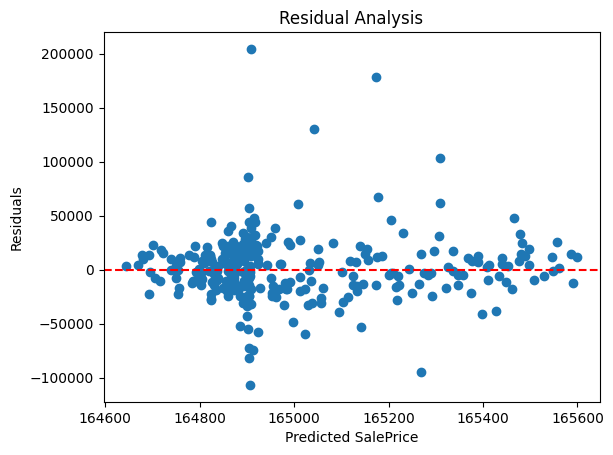

In [ ]:
import matplotlib.pyplot as plt
#residuals
residuals=y_test - y_pred_ridge
#residual plot
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color="red",linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()
#Check whether residuals are randomly distributed
#If the residuals are scattered randomly around the zero line without any clear pattern, then they are randomly distributed.
#What does this indicate about model quality?
#Randomly distributed residuals indicate that the model has captured most of the relationship between the features and SalePrice. The predictions are unbiased and the model fits the data well.
#Why is residual analysis important in regression?
#kIt helps evaluate model performance.
#It detects patterns that the model failed to capture.
#It identifies underfitting or overfitting.
#It verifies whether regression assumptions are satisfied.
#For the House Prices dataset, if the residual plot shows points randomly scattered around the zero line, the selected regression model is considered a good fit and provides reliable house price predictions.

##**Section 6: Business Insights &amp; Final Interpretation**

Q19. Feature Importance / Coefficient Analysis:
 For Ridge/Lasso/Elastic Net: identify features with highest coefficients
 For tree-based model if used: use feature_importances_
 Create a table:
Rank Feature
Name

Importance /
Coefficient Interpretation

1 ? ? ?
2 ? ? ?
3 ? ? ?
What do these features tell us about house pricing?

In [ ]:
import pandas as pd

# Use coefficients from the Ridge model (the best linear model)
coef_df = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": ridge.coef_
})
coef_df = coef_df.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)
print(coef_df.head(3))
#What do these features tell us about house pricing?
#OverallQual – Houses with higher construction and material quality tend to have higher prices.
#GrLivArea – Larger living space generally leads to higher house value.
#GarageCars – Homes with larger garages are usually more desirable and therefore more expensive.
#The most important features indicate that house quality, living area, and garage capacity are major factors affecting house prices. Houses that are larger, better built, and have more parking space generally sell for higher prices.

              Feature    Coefficient
225         PoolQC_Gd -101330.082653
91    Condition2_PosN  -90575.829206
117  RoofMatl_WdShngl   75870.271379
